## Lecture 3 Exercises: Ancestry and Genealogy

Create a Python script that takes as an input a folder of 23andMe files and constructs a matrix that defines the genotype for each SNP in the provided file. The matrix should include one row for each input 23andMe file and four columns for each ancestry informative SNP, per potential nucleotide. For each position in the matrix, record the number of nucleotides that each person has at that location, if the data is available. 


In [115]:
import pandas as pd
import os
import glob

def process_23andme_folder(folder_path):
    # Get all .txt files in the folder
    file_list = glob.glob(os.path.join(folder_path, "*.txt"))
    if not file_list:
        print("No files found in directory.")
        return None

    all_data = {}
    unique_snps = set()

    # --------- Read files and collect genotype counts
    for file_path in file_list:
        person_id = os.path.basename(file_path).strip('.txt')
        person_counts = {}
        
        with open(file_path, 'r') as f:
            for line in f:
                # Skip header
                if line.startswith('#') or not line.strip():
                    continue
                
                # Get SNP_id and Genotype
                parts = line.strip().split('\t')                
                rsid, _, _, genotype = parts
                
                # Record the number of nucleotides (A, T, G, C) that each person has at that location
                counts = {'A': 0, 'T': 0, 'G': 0, 'C': 0}
                for char in genotype:
                    if char in counts:
                        counts[char] += 1
                
                person_counts[rsid] = counts
                unique_snps.add(rsid)
        
        all_data[person_id] = person_counts

    # --------- Construct Genotype Matrix
    # Sort SNPs to ensure consistent column ordering
    sorted_snps = sorted(list(unique_snps))
    nucleotides = ['A', 'T', 'G', 'C']

    # Filter SNPs to include only those present in all samples
    common_snps = [ snp for snp in sorted_snps if all(snp in snp_data for snp_data in all_data.values()) ]
    
    # Create matrix columns: (SNP1, A), (SNP1, T)...
    columns = []
    for snp in common_snps:
        for nuc in nucleotides:
            columns.append(f"{snp}{nuc}")

    # Fill the matrix
    matrix_data = []
    row_ids = []
    for person_id, snp_data in all_data.items():
        row_ids.append(person_id)
        row_values = []
        for snp in common_snps:
            counts = snp_data.get(snp, {'A': 0, 'T': 0, 'G': 0, 'C': 0})
            row_values.extend([counts['A'], counts['T'], counts['G'], counts['C']])
        matrix_data.append(row_values)

    # Convert to DataFrame
    df = pd.DataFrame(matrix_data, index=row_ids, columns=columns)
    return df



Run this program on the five samples here https://karchinlab.org/share/aag_spr2026/lecture_3_exercises/5-PGP-genotype-files.zip 
What size is the resultant matrix?


In [116]:
folder = "/Users/kmlanderos/Documents/Johns_Hopkins/Spring_2026/Annotate_a_Genome/data/excercise3/5-PGP-genotype-files"
genotype_matrix = process_23andme_folder(folder)
print(genotype_matrix.head())
print(genotype_matrix.shape)

                                                    i1000009A  i1000009T  \
user5105_file3621_yearofbirth_unknown_sex_XX.23...          0          0   
user5902_file4372_yearofbirth_1983_sex_XX.23andme           0          0   
user5917_file4386_yearofbirth_1979_sex_XX.23andme           0          0   
genome_Joshua_Yoakem_v5_Full_20250129211749                 0          0   
user5107_file3623_yearofbirth_1986_sex_XX.23andme           0          0   

                                                    i1000009G  i1000009C  \
user5105_file3621_yearofbirth_unknown_sex_XX.23...          1          0   
user5902_file4372_yearofbirth_1983_sex_XX.23andme           1          0   
user5917_file4386_yearofbirth_1979_sex_XX.23andme           1          0   
genome_Joshua_Yoakem_v5_Full_20250129211749                 1          0   
user5107_file3623_yearofbirth_1986_sex_XX.23andme           1          0   

                                                    i3000001A  i3000001T  \
user5105_f

Now modify the program to construct an array that counts the number of individuals missing a genotype for each SNP in the Seldin et al data. Plot a histogram of these values. Do the majority of the SNPs have good coverage in this data?

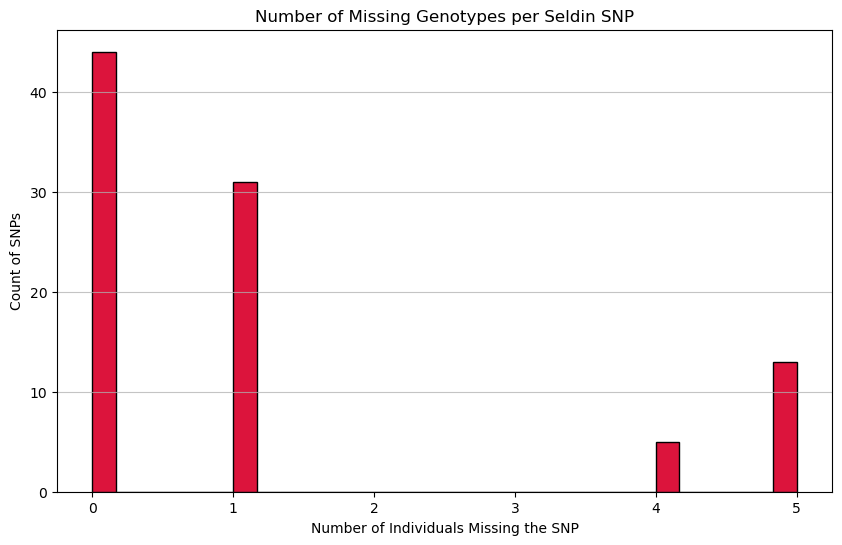

In [125]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_seldin_missingness(pgp_folder, csv):
    # Load the Seldin manifest to get our target SNPs
    if not os.path.exists(csv):
        raise FileNotFoundError(f"Cannot find CSV at {csv}")
        
    snps_df = pd.read_csv(csv)
    # Extract the rsIDs
    target_snps = set(snps_df['NCBI'].dropna().astype(str).str.strip())
    
    # Get all PGP text files
    file_list = glob.glob(os.path.join(pgp_folder, "*.txt"))
    total_people = len(file_list)

    # Track valid calls for target SNPs only
    valid_calls = {snp: 0 for snp in target_snps} # Initialize counts to 0 for all target SNPs

    # Track cohort SNPS present in AIM panel
    cohort_SNPs = set()

    for file_path in file_list:
        with open(file_path, 'r') as f:
            for line in f:
                if line.startswith('#') or not line.strip():
                    continue
                
                parts = line.strip().split('\t')
                if len(parts) < 4:
                    continue
                    
                rsid, _, _, genotype = parts
                
                # If it's a target SNP and has a valid genotype, count it
                if rsid in target_snps:
                    if genotype not in ['--', 'NN']:
                        valid_calls[rsid] += 1
                    cohort_SNPs.add(rsid) # Add SNP to cohort SNPS that are in AIM panel

    # Calculate missing counts (Total people - people with valid calls)
    missing_array = np.array([total_people - valid_calls[snp] for snp in target_snps])
    
    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(missing_array, bins=30, color='crimson', edgecolor='black')
    plt.title('Number of Missing Genotypes per Seldin SNP')
    plt.xlabel('Number of Individuals Missing the SNP')
    plt.ylabel('Count of SNPs')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Return SNPs from AIM panel that were never seen in cohort
    absent_SNPs = target_snps.difference(cohort_SNPs)

    return missing_array, absent_SNPs

# --- Paths
pgp_folder = "/Users/kmlanderos/Documents/Johns_Hopkins/Spring_2026/Annotate_a_Genome/data/excercise3/5-PGP-genotype-files"
seldin_csv = "/Users/kmlanderos/Documents/Johns_Hopkins/Spring_2026/Annotate_a_Genome/data/excercise3/Seldin_AIMS_SNPs.csv"

# Run  function
missing_array, absent_SNPs = analyze_seldin_missingness(pgp_folder, seldin_csv)

In [123]:
data = {'Missing_individuals': missing_array}
df = pd.DataFrame(data)
frequency_table = df['Missing_individuals'].value_counts()
frequency_table

Missing_individuals
0    44
1    31
5    13
4     5
Name: count, dtype: int64

In [128]:
print(f"{len(absent_SNPs)} SNPs from the AIM panel were never seen in cohort")
print(absent_SNPs)

13 SNPs from the AIM panel were never seen in cohort
{'rs818386', 'rs948028', 'rs10839880', 'rs12544346', 'rs10108270', 'rs10513300', 'rs1871428', 'rs2306040', 'rs7745461', 'rs2986742', 'rs874299', 'rs316598', 'rs1040404'}


Next, write a code that uses SciKit-learn to run principal component analysis (PCA) and then plot the first two principal components. The input to the code would be a matrix, as generated in question1.

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def plot_pca(data):

    # Standardization 
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)

    # Fit the PCA model
    pca = PCA(n_components=2)
    components = pca.fit_transform(scaled_data)

    # Extract explained variance to label the axes
    var_pc1 = pca.explained_variance_ratio_[0] * 100
    var_pc2 = pca.explained_variance_ratio_[1] * 100

    # Generate the scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(components[:, 0], components[:, 1], alpha=0.6, color='dodgerblue', edgecolor='k')
    
    plt.title('PCA of Genotype Matrix')
    plt.xlabel(f'PC1 ({var_pc1:.2f}% Explained Variance)')
    plt.ylabel(f'PC2 ({var_pc2:.2f}% Explained Variance)')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.show()

Run this PCA code on the "5-PGP-genotype-files" to produce a PCA plot.

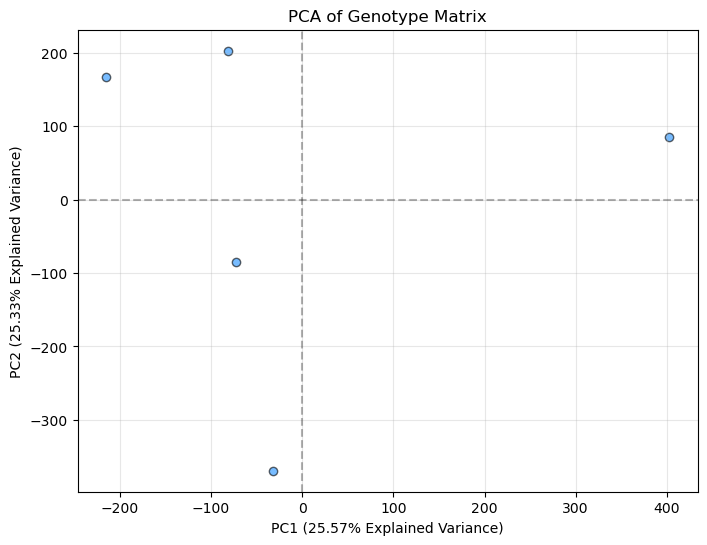

In [75]:
plot_pca(genotype_matrix)

Repeat the above analysis on the 33 samples here to produce a second PCA plot. (10 points) https://karchinlab.org/share/aag_spr2026/lecture_3_exercises/33-PGP-genotype-files.zip  These 33 individuals are from diverse global populations, and each filename includes the self-reported global population for that individual.


In [77]:
folder = "/Users/kmlanderos/Documents/Johns_Hopkins/Spring_2026/Annotate_a_Genome/data/excercise3/33-PGP-genotype-files"
genotype_matrix_33 = process_23andme_folder(folder)


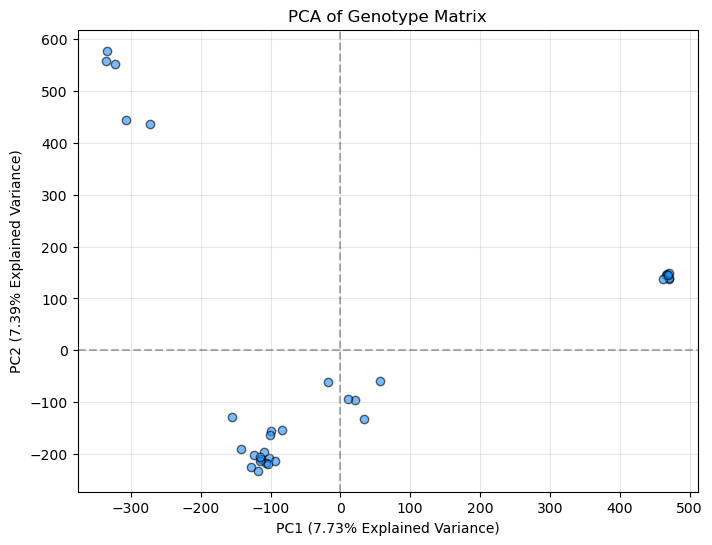

In [79]:
plot_pca(genotype_matrix_33)

Modify your PCA plot code to color the dot representing each of the 33 individuals by their self-reported global population. By visual inspection of the plot, do you see individuals from the same self-reported populations clustering together in PCA space? Describe the visual appearance of the PCA plot. Are there any individuals who are not clustered with others having the same self-reported global population? If yes, provide an explanation of why this might be the case.


In [129]:
import seaborn as sns

def plot_pca_by_population(data, population):

    # Standardization 
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)

    # Fit the PCA model
    pca = PCA(n_components=3)
    components = pca.fit_transform(scaled_data)
    components_df = pd.DataFrame(components, columns=['PC1', 'PC2', 'PC3'])
    components_df['Population'] = population

    # Extract explained variance to label the axes
    var_pc1 = pca.explained_variance_ratio_[0] * 100
    var_pc2 = pca.explained_variance_ratio_[1] * 100
    var_pc3 = pca.explained_variance_ratio_[2] * 100

    # Generate the scatter plot
    sns.scatterplot(data=components_df, x='PC1', y='PC2', hue='Population')
    plt.title('Scatter Plot Colored by Global Population')
    plt.xlabel(f'PC1 ({var_pc1:.2f}% Explained Variance)')
    plt.ylabel(f'PC2 ({var_pc2:.2f}% Explained Variance)')
    plt.show()

    # Generate the scatter plot
    sns.scatterplot(data=components_df, x='PC1', y='PC3', hue='Population')
    plt.title('Scatter Plot Colored by Global Population')
    plt.xlabel(f'PC1 ({var_pc1:.2f}% Explained Variance)')
    plt.ylabel(f'PC3 ({var_pc3:.2f}% Explained Variance)')
    plt.show()

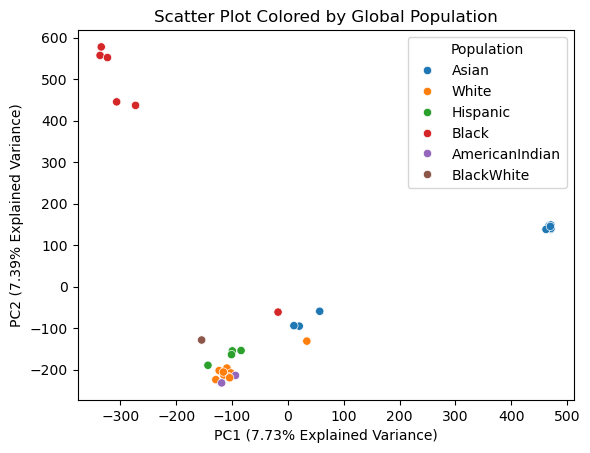

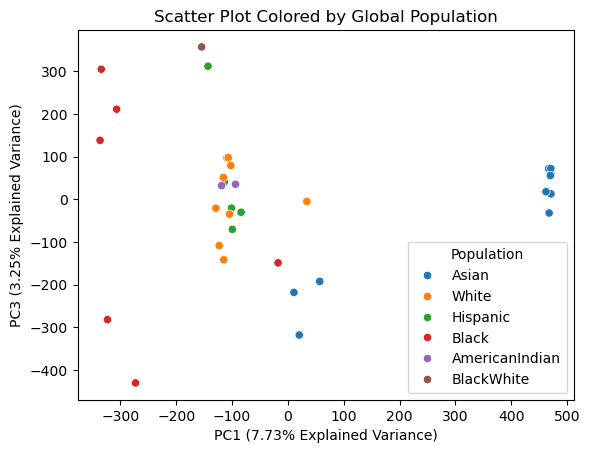

In [133]:
population = [person.split("_")[2] for person in genotype_matrix_33.index]
plot_pca_by_population(genotype_matrix_33, population)